In [57]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import photutils.isophote as isoph
import photutils.centroids as cen
from photutils.aperture import EllipticalAperture
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from scipy.ndimage import rotate,zoom,shift
from cmath import polar,rect
from scipy.optimize import curve_fit
import pandas as pd

In [2]:
NGC2403_g = fits.open('NGC_2403_SDSS_g_bms2014.fits')
#NGC2403_g = fits.open('NGC_2403_I_g_fgg1996.fits')

In [3]:
image_g = NGC2403_g[0].data
center = cen.centroid_2dg(image_g)

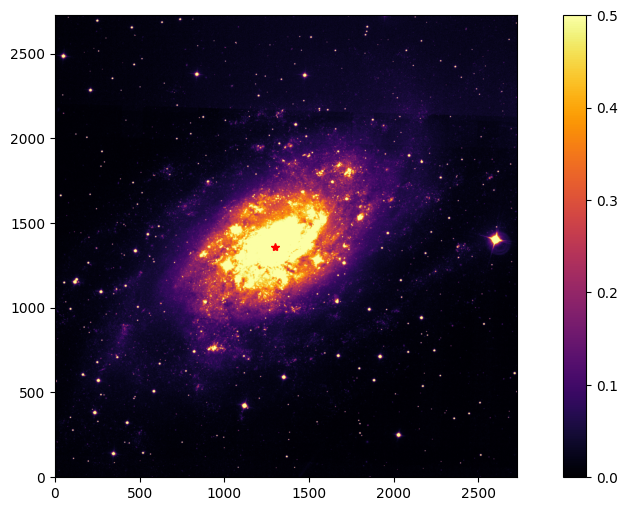

In [4]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(image_g,origin='lower',vmin=0,vmax=0.5,cmap='inferno')
ax.plot(center[0],center[1],'r*')
fig.colorbar(im)
plt.show()

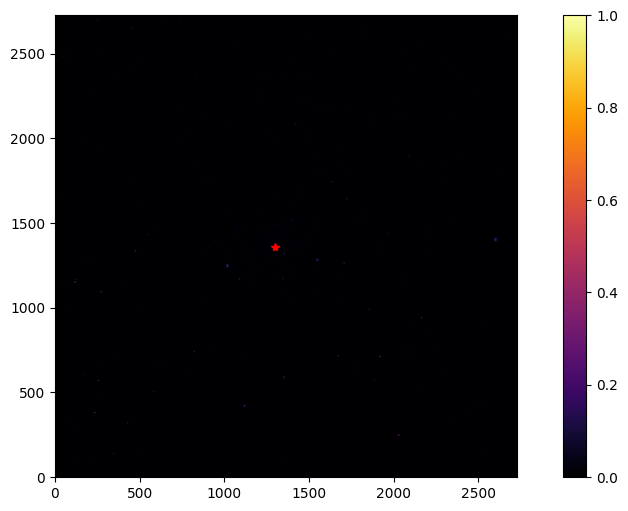

In [5]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(image_g/image_g.max(),origin='lower',cmap='inferno')
ax.plot(center[0],center[1],'r*')
fig.colorbar(im)
plt.show()

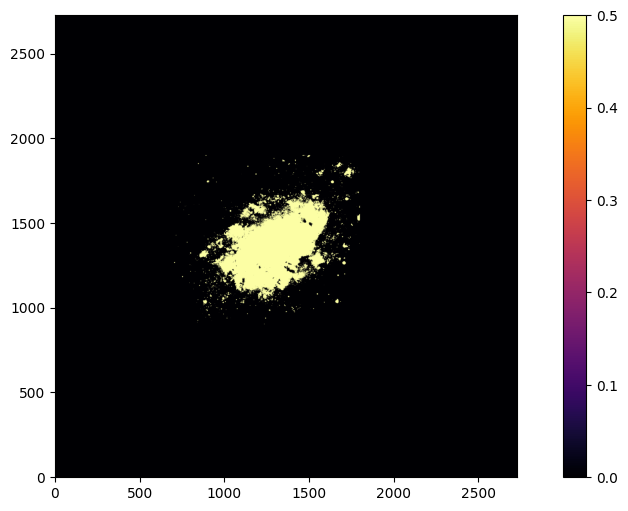

In [6]:
cond0 = image_g>=0.35
cond = cond0[900:1900,700:1800]

dist = np.zeros_like(cond0)
dist[900:1900,700:1800] = cond

fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(dist,origin='lower',vmin=0,vmax=0.5,cmap='inferno')
#ax.plot(center[0],center[1],'r*')
fig.colorbar(im)
plt.show()

In [7]:
xx = np.arange(cond0.shape[0])
yy = np.arange(cond0.shape[0])

XX,YY = np.meshgrid(xx,yy)

xs_dist = XX[dist]
ys_dist = YY[dist]

In [8]:
cov = np.cov(xs_dist,ys_dist)
eigvals, eigvecs = np.linalg.eigh(cov)  # eigh porque la covarianza es simétrica

# Ordenar de mayor a menor
order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

angle = np.arctan(eigvecs[1,0]/eigvecs[0,0])

sma = 3*eigvals[0]**0.5
eps = 1 - eigvals[1]/eigvals[0]

In [9]:
geometry = isoph.EllipseGeometry(x0=center[0], y0=center[1], sma=sma, eps=eps,
                           pa=angle)

In [10]:
aper = EllipticalAperture((geometry.x0, geometry.y0), geometry.sma,
                          geometry.sma * (1 - geometry.eps),
                          geometry.pa)

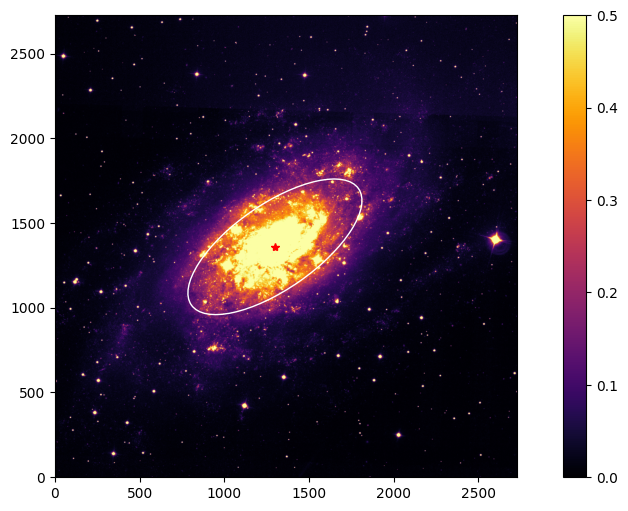

In [11]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(image_g,origin='lower',vmin=0,vmax=0.5,cmap='inferno')
ax.plot(center[0],center[1],'r*')
aper.plot(color='white')
fig.colorbar(im)
plt.show()

In [12]:
np.random.seed(1)
for i in range(image_g.shape[0]):
    for j in range(image_g.shape[1]):
        if image_g[i,j]>0.5:
            image_g[i,j]=0.5+1e-7*np.random.random()
        elif image_g[i,j]<0.0:
            image_g[i,j]=1e-7*np.random.random()


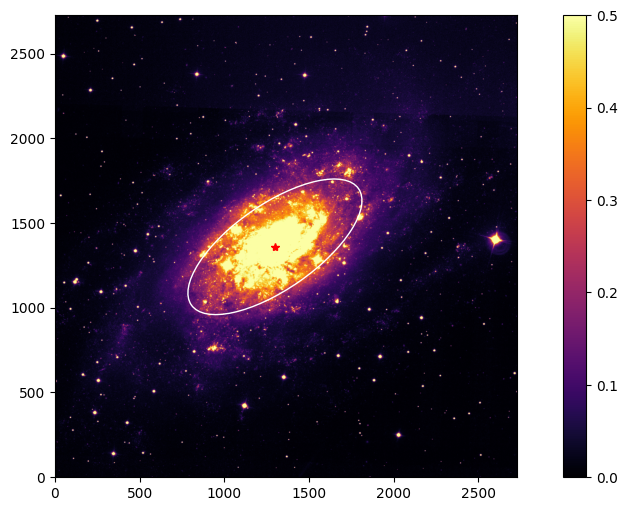

In [13]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(image_g,origin='lower',cmap='inferno')
ax.plot(center[0],center[1],'r*')
aper.plot(color='white')
fig.colorbar(im)
plt.show()

In [14]:
ellipse = isoph.Ellipse(image_g,geometry)
isolist = ellipse.fit_image()

In [15]:
for i in isolist:
    print(i.eps)

0.0
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.95
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4389759271788979
0.4840456357489339
0.6264418908622568
0.6

In [16]:
isogeom = []
isoaper = []
for iso in isolist[1:]:
    isogeom.append(isoph.EllipseGeometry(x0=iso.x0, y0=iso.y0, sma=iso.sma, eps=iso.eps,
                           pa=iso.pa))
    
for geom in isogeom:
    isoaper.append(EllipticalAperture((geom.x0, geom.y0), geom.sma, geom.sma * (1 - geom.eps), geom.pa))

In [17]:
isogeom[-1].sma

1886.432058233644

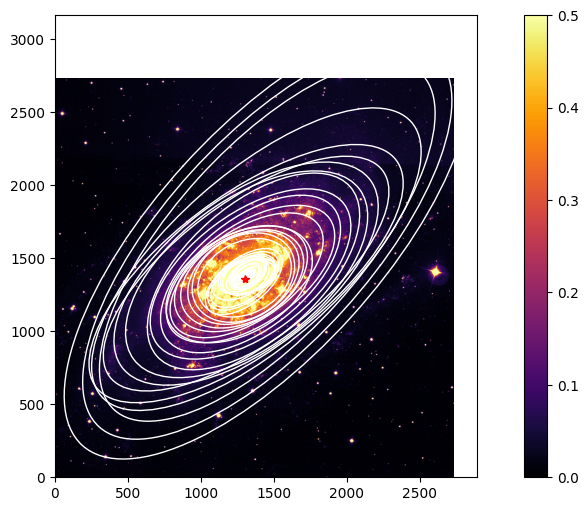

In [18]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(image_g,origin='lower',cmap='inferno')
ax.plot(center[0],center[1],'r*')
#aper.plot(color='white')
for i in range(0,len(isoaper)):
    isoaper[i].plot(color='white')
fig.colorbar(im)
plt.show()

In [19]:
eps_mean = np.mean(isolist.eps)
pa_mean = np.mean(isolist.pa)
x0_mean = np.mean(isolist.x0)
y0_mean = np.mean(isolist.y0)


In [20]:
mask = isolist.ellip_err==isolist.ellip_err.max()
index = np.arange(0,len(isolist))
index[mask]

array([20])

In [21]:
isolist[7].to_table()

sma,intens,intens_err,ellipticity,ellipticity_err,pa,pa_err,grad,grad_error,grad_rerror,x0,x0_err,y0,y0_err,ndata,nflag,niter,stop_code
,,,,,deg,deg,,,,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,object,object,float64,float64,float64,float64,int64,int64,int64,int64
0.9209294379103524,0.5000000527278787,6.8872183766164305e-09,0.4840456357489339,0.037521400582341345,34.84519418595028,1.6103109296498717,-1.2666739964723119e-07,None,None,1313.012047513746,0.02676526557263421,1382.6970969051965,0.021500731213906648,13,0,1,5


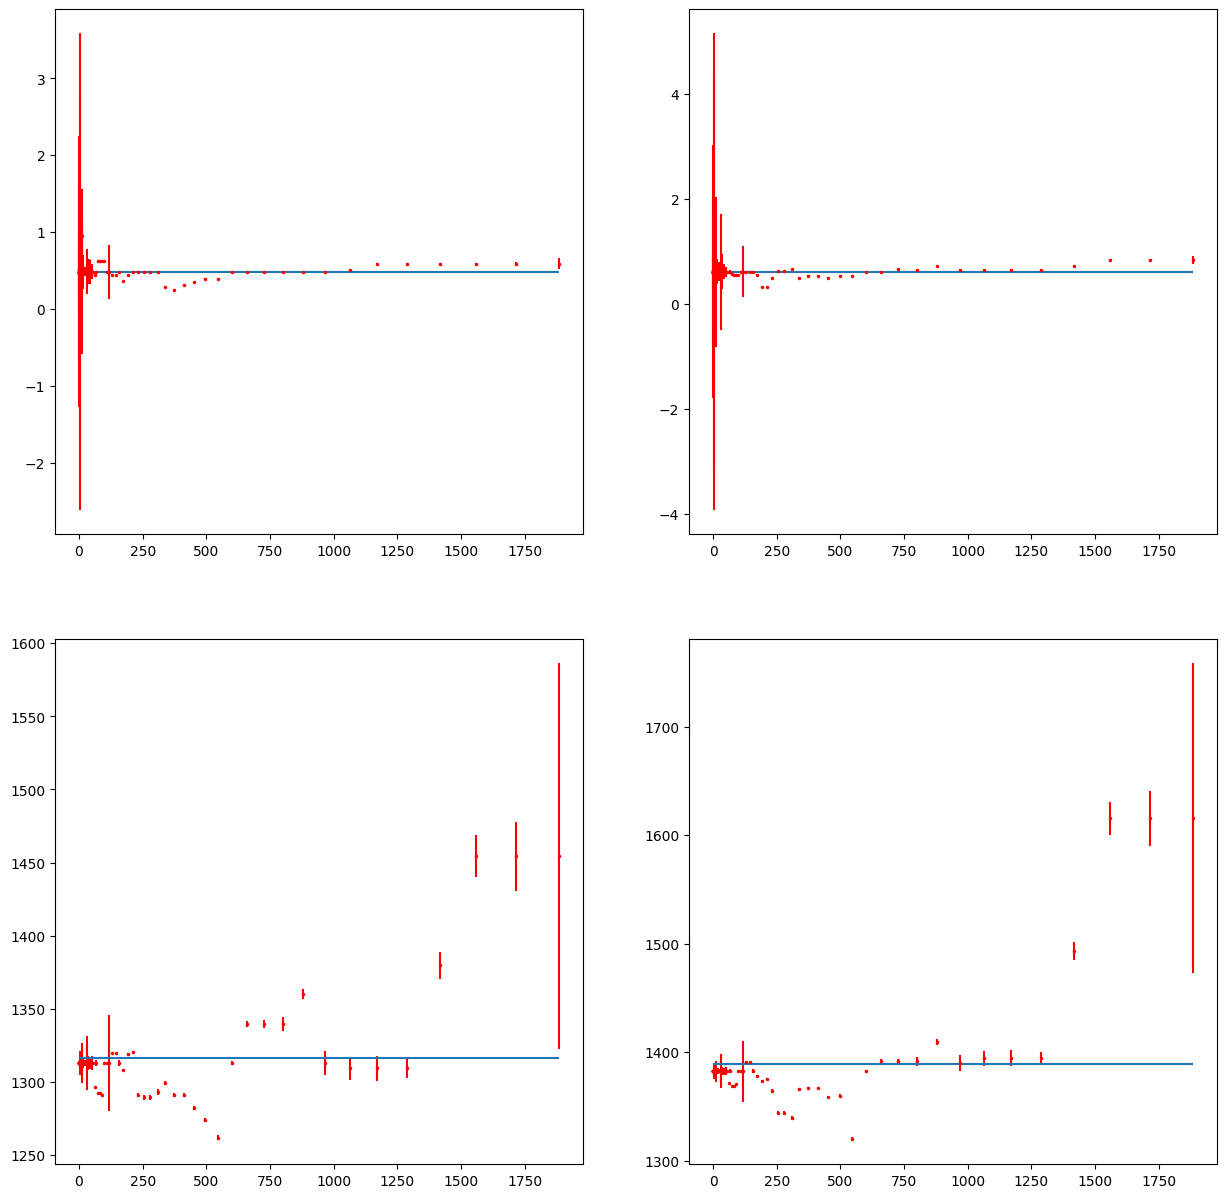

In [22]:
fig,ax = plt.subplots(2,2,figsize=(15,15))

ax[0,0].errorbar(isolist.sma[1:],isolist.eps[1:],yerr=isolist.ellip_err[1:],linestyle='None',marker='.',markersize=3,color='r')
ax[0,1].errorbar(isolist.sma[1:],isolist.pa[1:],yerr=isolist.pa_err[1:],linestyle='None',marker='.',markersize=3,color='r')
ax[1,0].errorbar(isolist.sma[1:],isolist.x0[1:],yerr=isolist.x0_err[1:],linestyle='None',marker='.',markersize=3,color='r')
ax[1,1].errorbar(isolist.sma[1:],isolist.y0[1:],yerr=isolist.y0_err[1:],linestyle='None',marker='.',markersize=3,color='r')

ax[0,0].hlines(eps_mean,isolist.sma[0],isolist.sma[-1])
ax[0,1].hlines(pa_mean,isolist.sma[0],isolist.sma[-1])
ax[1,0].hlines(x0_mean,isolist.sma[0],isolist.sma[-1])
ax[1,1].hlines(y0_mean,isolist.sma[0],isolist.sma[-1])

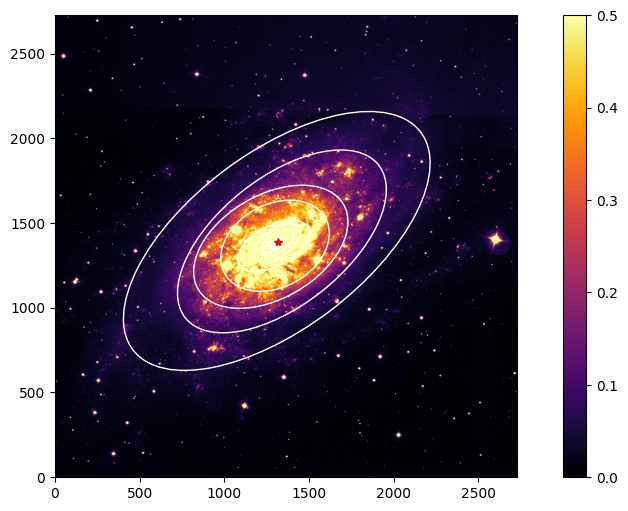

In [23]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(image_g,origin='lower',cmap='inferno')
ax.plot(x0_mean,y0_mean,'r*')
#aper.plot(color='white')
for i in range(0,len(isoaper)-4,4):
    isoaper[i].plot(color='white')
fig.colorbar(im)
plt.show()

In [24]:
model_image = isoph.build_ellipse_model(image_g.shape, isolist[1:-4])

In [25]:
residual = image_g - model_image

In [26]:
inc = np.arccos(1-eps_mean)*180/np.pi
inc

58.91151933045546

Text(0.5, 1.0, 'Data')

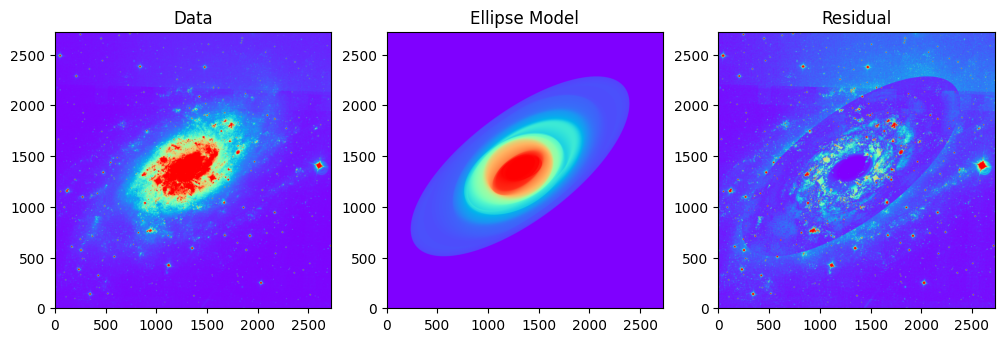

In [27]:
fig, (ax1, ax2, ax3) = plt.subplots(figsize=(10, 5), nrows=1, ncols=3)
fig.subplots_adjust(left=0.04, right=0.98, bottom=0.02, top=0.98)
ax1.imshow(image_g, origin='lower',cmap='rainbow')
ax2.imshow(model_image, origin='lower',cmap='rainbow')
ax2.set_title('Ellipse Model')
im = ax3.imshow(np.abs(residual),vmax=0.2, origin='lower',cmap='rainbow')
#fig.colorbar(im)
ax3.set_title('Residual')
ax1.set_title('Data')

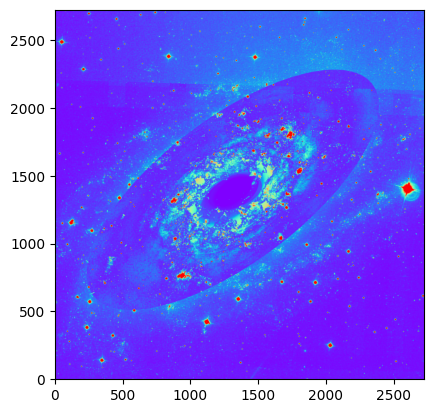

In [28]:
plt.imshow(np.abs(residual), origin='lower',cmap='rainbow',vmax=0.2)

In [29]:
isolist.intens

array([0.50000002, 0.50000004, 0.50000004, 0.50000004, 0.50000004,
       0.50000005, 0.50000005, 0.50000005, 0.50000006, 0.50000006,
       0.50000006, 0.50000006, 0.50000006, 0.50000006, 0.50000005,
       0.50000005, 0.50000005, 0.50000005, 0.50000005, 0.50000004,
       0.50000004, 0.50000004, 0.50000004, 0.50000004, 0.50000004,
       0.50000005, 0.50000006, 0.50000006, 0.50000006, 0.50000005,
       0.50000005, 0.50000005, 0.50000005, 0.50000005, 0.50000005,
       0.50000004, 0.50000005, 0.50000005, 0.50000005, 0.50000005,
       0.50000005, 0.50000005, 0.50000005, 0.50000005, 0.50000004,
       0.50000005, 0.50000005, 0.50000005, 0.50000005, 0.50000005,
       0.50000005, 0.50000005, 0.50000005, 0.50000005, 0.50000005,
       0.50000005, 0.50000005, 0.50000005, 0.4998953 , 0.50000005,
       0.49982888, 0.49864421, 0.49468539, 0.49643912, 0.49210226,
       0.48063273, 0.47068667, 0.44931112, 0.41590882, 0.35989079,
       0.29069296, 0.26737513, 0.2364044 , 0.19727639, 0.15564

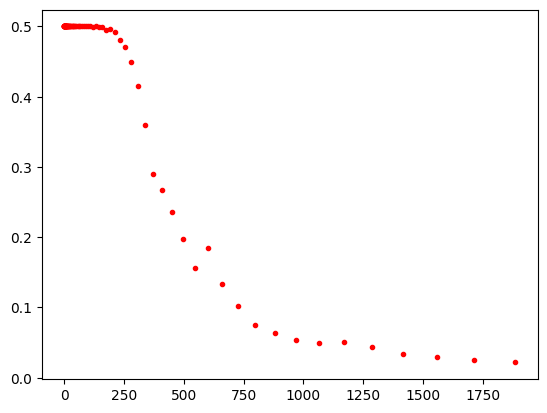

In [30]:
plt.plot(isolist.sma,isolist.intens,'r.')

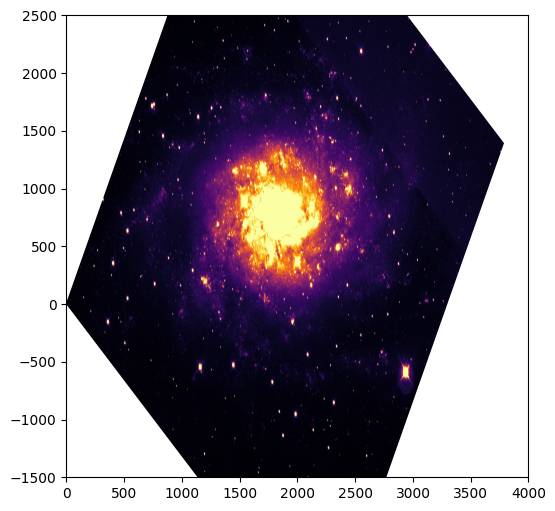

In [31]:
fig, ax = plt.subplots(figsize=(12,6))
#im = ax.imshow(image_g,origin='lower',cmap='inferno')
#aper.plot(color='white')
# for i in range(0,len(isoaper)-4,4):
#     isoaper[i].plot(color='white')


tr = transforms.Affine2D().rotate_deg(-pa_mean*180/np.pi).scale(1,1/(1-eps_mean))

ax.imshow(image_g,origin='lower',cmap='inferno', transform=tr + ax.transData)
ax.set(xlim=(0,4000),ylim=(-1500,2500))
ax.set_box_aspect(1)
plt.show()

In [164]:
corrected_image = rotate(image_g,pa_mean*180/np.pi,reshape=False)
corrected_image = zoom(corrected_image,(1/(1-eps_mean),1))

#brazo1 = np.array([[1326,2472],[1423,2529],[1504,2578],[1601,2648],[1618,2761],[1607,2853],[1564,2983],[1531,3128],[1380,3171],[1223,3171],[1105,3064]])
brazo2 = np.array([[1375,2891],[1250,2907],[1121,2842],[1051,2723],[1062,2556],[1126,2410],[1234,2362],[1407,2335],[1585,2362]])

brazo1 = np.array([[1366,2559],[1434,2547],[1495,2565],[1584,2624],[1636,2759],[1630,2866],[1599,2964],[1550,3059],[1474,3136],[1348,3176],[1225,3166],[1127,3124]])

In [165]:
center_mean = np.array([x0_mean,y0_mean])
center_img = np.array([image_g.shape[0]/2,image_g.shape[1]/2])

corrected_center = center_mean - center_img
rot_mat = np.array([[np.cos(pa_mean),np.sin(pa_mean)],[-np.sin(pa_mean),np.cos(pa_mean)]])

corrected_center = rot_mat@corrected_center
corrected_center += center_img
corrected_center[1] *= 1/(1-eps_mean)

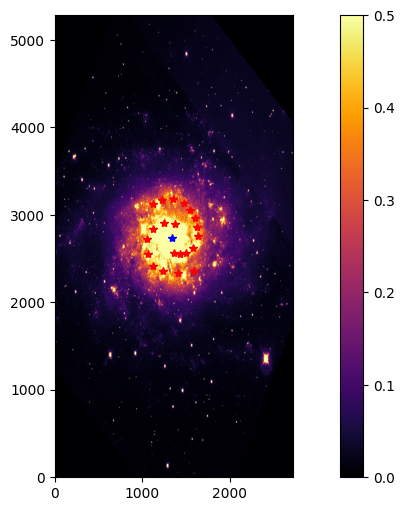

In [166]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(corrected_image,origin='lower',vmin=0,vmax=0.5,cmap='inferno')
ax.plot(brazo1[:,0],brazo1[:,1],'r*')
ax.plot(brazo2[:,0],brazo2[:,1],'r*')
ax.plot(corrected_center[0],corrected_center[1],'b*')
fig.colorbar(im)
plt.show()

In [154]:
z_brazo1 = (brazo1[:,0]-corrected_center[0])+1j*(brazo1[:,1]-corrected_center[1])
z_brazo2 = (brazo2[:,0]-corrected_center[0])+1j*(brazo2[:,1]-corrected_center[1])

polar = np.vectorize(polar)

r_brazo1, th_brazo1 = polar(z_brazo1)
r_brazo2, th_brazo2 = polar(z_brazo2)

df_brazo1 = pd.DataFrame()
df_brazo1['r'] = r_brazo1
df_brazo1['th'] = th_brazo1

df_brazo2 = pd.DataFrame()
df_brazo2['r'] = r_brazo2
df_brazo2['th'] = th_brazo2%(2*np.pi)

df_brazo1 = df_brazo1.sort_values(['th'])
df_brazo2 = df_brazo2.sort_values(['th'])

In [155]:
logspiral = lambda th,a,b: a*b**th

In [156]:
pars_brazo1,cov_brazo1 = curve_fit(logspiral,df_brazo1['th'],df_brazo1['r'])
pars_brazo2,cov_brazo2 = curve_fit(logspiral,df_brazo2['th'],df_brazo2['r'])

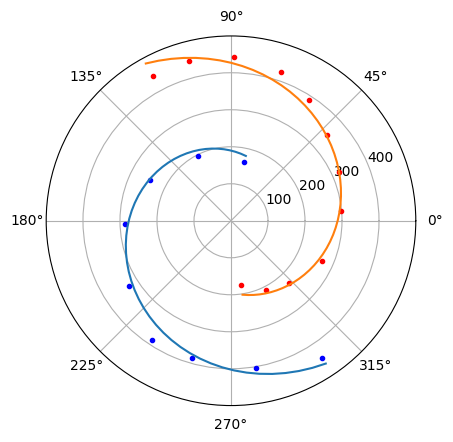

In [158]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(df_brazo1['th'],df_brazo1['r'],'r.')
ax.plot(df_brazo2['th'],df_brazo2['r'],'b.')
ax.plot(ths2,logspiral(ths2,*pars_brazo2))
ax.plot(ths1,logspiral(ths1,*pars_brazo1))

In [162]:
rect = np.vectorize(rect)
xs_brazo1 = rect(r_brazo1,th_brazo1).real+corrected_center[0]
ys_brazo1 = rect(r_brazo1,th_brazo1).imag+corrected_center[1]
xs_brazo2 = rect(r_brazo2,th_brazo2).real+corrected_center[0]
ys_brazo2 = rect(r_brazo2,th_brazo2).imag+corrected_center[1]

xs_brazo1_fit = rect(logspiral(ths1,*pars_brazo1),ths1).real+corrected_center[0]
ys_brazo1_fit = rect(logspiral(ths1,*pars_brazo1),ths1).imag+corrected_center[1]
xs_brazo2_fit = rect(logspiral(ths2,*pars_brazo2),ths2).real+corrected_center[0]
ys_brazo2_fit = rect(logspiral(ths2,*pars_brazo2),ths2).imag+corrected_center[1]

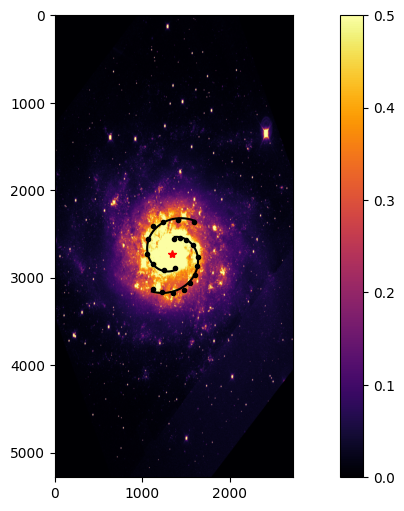

In [169]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(corrected_image,vmin=0,vmax=0.5,cmap='inferno')
ax.plot(xs_brazo1,ys_brazo1,'k.')
ax.plot(xs_brazo2,ys_brazo2,'k.')
ax.plot(corrected_center[0],corrected_center[1],'r*')
ax.plot(xs_brazo1_fit,ys_brazo1_fit,'k')
ax.plot(xs_brazo2_fit,ys_brazo2_fit,'k')
fig.colorbar(im)
plt.show()